In [1]:
import numpy as np
import matplotlib.pyplot as plt

#method for least squares linear regression
def lst_sqr(X, Y):
    n = len(X)
    sum_x = sum(X)
    sum_y = sum(Y)
    sum_xx = sum(X**2)
    sum_xy = sum(X * Y)
    
    m = (n * sum_xy - sum_x * sum_y)/(n * sum_xx - (sum_x ** 2))
    c = (sum_y - m * sum_x)/n
    return m, c

#code for polynomial fitting
def poly_fit(x, y, degree):
    n = len(x)
    #Create the Vandermonde Matrix
    A = np.zeros((n, degree + 1))
    for i in range(degree + 1):
        A[:,i] = x**i
    #Creat the normal equations
    ATA = A.T @ A
    ATy = A.T @ y
    #solve for coefficients
    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs

#evaluates the polynomial at a given x
def evaluate_poly(x_val, coeffs):
    y_val = 0
    for i, c in enumerate(coeffs):
        y_val += c * (x_val**i)
    return y_val

#Solves for the cubic spline
def fit_cubic_spline(x, y):
    #set up tridiagonal matrix
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])             # Right-hand side vector
    
    #solve tridiagonal system
    n = len(B)
    # Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = D[-1] / B[-1]
    for i in range(n-2, -1, -1):
        x[i] = (D[i] - C[i] * x[i+1]) / B[i]
    #Solve for moments array with boundary conditions
    M_internal = x
    M = np.zeros(len(x)+2)
    M[1:-1] = x
    return M
      
#evaluates the points of the cubic spline
def evaluate_spline(x_val, x, y, M):
    n = len(x)
    h = np.diff(x)
    # Find which interval x_val falls into
    for i in range(n-1):
        if x[i] <= x_val <= x[i+1]:
            term1 = (M[i] / (6 * h[i])) * (x[i+1] - x_val)**3
            term2 = (M[i+1] / (6 * h[i])) * (x_val - x[i])**3
            term3 = (y[i] / h[i] - (M[i] * h[i]) / 6) * (x[i+1] - x_val)
            term4 = (y[i+1] / h[i] - (M[i+1] * h[i]) / 6) * (x_val - x[i])
            return term1 + term2 + term3 + term4
    return None


In [2]:
#Part A and B data entry
# Indices based on the 55-quarter range (2010 Q1 to 2023 Q4)
x_data = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 55])

# GDP Growth (%) values from the PDF table
y_data = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 
                   1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


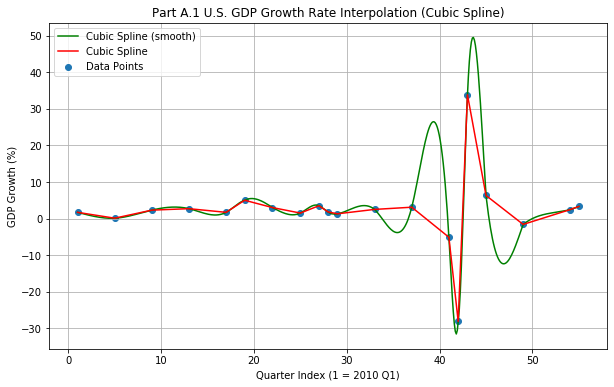

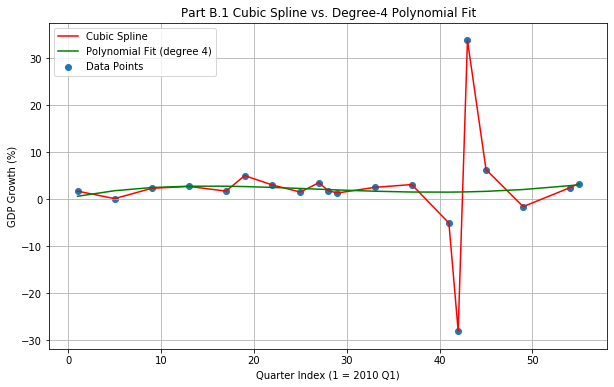

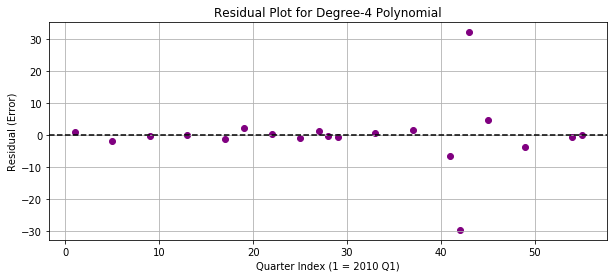

The calculated slope for the non-COVID period is: -0.0022


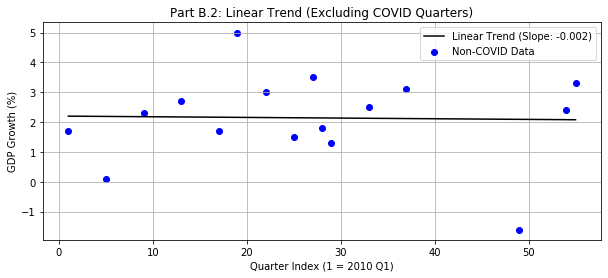

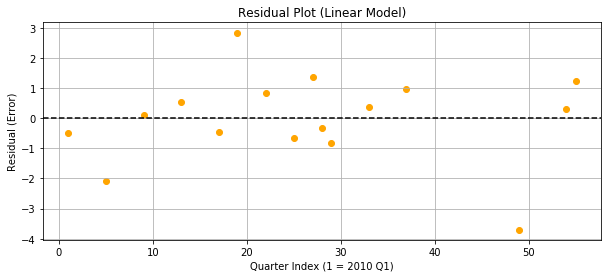

In [3]:
#Part A.1 & A.2
M = fit_cubic_spline(x_data, y_data)

y_val = [evaluate_spline(val, x_data, y_data, M) for val in x_data]
x_smooth = np.linspace(1, 55, 500)
y_smooth = [evaluate_spline(val, x_data, y_data, M) for val in x_smooth]


plt.figure(figsize=(10, 6))
plt.plot(x_smooth, y_smooth, 'g-', label='Cubic Spline (smooth)')
plt.plot(x_data, y_val, 'r-', label='Cubic Spline')
plt.scatter(x_data, y_data, label='Data Points')
plt.title('Part A.1 U.S. GDP Growth Rate Interpolation (Cubic Spline)')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('GDP Growth (%)')
plt.grid(True)
plt.legend()
plt.show()

#Part B.1
degree = 4
poly_coeffs = poly_fit(x_data, y_data, degree)
y_poly = evaluate_poly(x_data, poly_coeffs)
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_val, 'r-', label='Cubic Spline')
plt.plot(x_data, y_poly, 'g-', label="Polynomial Fit (degree 4)")
plt.scatter(x_data, y_data, label='Data Points')
plt.title('Part B.1 Cubic Spline vs. Degree-4 Polynomial Fit')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('GDP Growth (%)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate predicted values at the specific data points
y_poly_pred = evaluate_poly(x_data, poly_coeffs)
residuals = y_data - y_poly_pred

# Plot Residuals
plt.figure(figsize=(10, 4))
plt.scatter(x_data, residuals, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot for Degree-4 Polynomial')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('Residual (Error)')
plt.grid(True)
plt.show()

#Part B.2
covid_mask = (x_data >= 41) & (x_data <= 45)
x_filtered = x_data[~covid_mask]
y_filtered = y_data[~covid_mask]
m, c = lst_sqr(x_filtered, y_filtered)
print(f"The calculated slope for the non-COVID period is: {m:.4f}")

#linear plot
y_linear_fit = m * x_filtered + c
plt.figure(figsize=(10, 4))
plt.scatter(x_filtered, y_filtered, color='blue', label='Non-COVID Data')
plt.plot(x_filtered, y_linear_fit, 'k-', label=f'Linear Trend (Slope: {m:.3f})')
plt.title('Part B.2: Linear Trend (Excluding COVID Quarters)')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('GDP Growth (%)')
plt.grid(True)
plt.legend()
plt.show()

#linear residuals
residuals_linear = y_filtered - y_linear_fit
plt.figure(figsize=(10, 4))
plt.scatter(x_filtered, residuals_linear, color='orange')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot (Linear Model)')
plt.ylabel('Residual (Error)')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.grid(True)
plt.show()

In [4]:
#Part C
#method to calculate RMSE
def calculate_rmse(y_actual, y_predicted):
    mse = np.mean((y_actual - y_predicted)**2)
    return np.sqrt(mse)

y_spline_at_data = [evaluate_spline(x, x_data, y_data, M) for x in x_data]
spline_rmse = calculate_rmse(y_data, y_spline_at_data)
poly_rmse = calculate_rmse(y_data, y_poly_pred)
linear_rmse = calculate_rmse(y_filtered, y_linear_fit)

print(f"Cubic Spline RMSE: {spline_rmse: .4f}")
print(f"Polynomial RMSE: {poly_rmse: .4f}")
print(f"Linear Regression RMSE: {linear_rmse: .4f}")


Cubic Spline RMSE:  0.0000
Polynomial RMSE:  10.0316
Linear Regression RMSE:  1.4431


# Part A: Cubic Spline Interpolation

1. There are n-2 unknown internal equations to be solved for, in this case n=20 for the subset. There are three continuity conditions at the internal knots, C0, that the values of splines must be equal at the knots, C1, that their first derivatives must be equal at the knots, and C2, that their second derivatives must be equal at the knots. A natural spline is defined by the boundary condition that the endpoints, M1 and Mn, must have a second derivative equal to 0.
2. The interpolant is visually smooth when evaluated at every quarter, However, because it must pass exactly through every point, it often "overshoots" or curves excessively between data points to maintain smoothness. This is especially evident during the COVID fluctuations, where the spline creates a sharp "v" shape that may not realistically represent the economic transition.
3. The Runge phenomenon describes undesirable oscillation at the edges of an interval of a high degree polynomial interpolation. Cubic splines usually avoid this, however the COVID outlier creates a sharp v in the interpolation, inducing oscillations. Interpolations create smooth paths due to passing exactly through every data point, however they suffer from oscillations and instability from outliers and near edges. A smoothing spline would be preferable here since it would ignore some of the noise of outliers to maintain a more realistic curve.

# Part B: Polynomial & Least Squares Comparison

1. The degree 4 polynomial better captures the trend as a whole, but the cubic spline interpolation better reproduces specific data points. Approximation is better at capturing and predicting long term trends than interpolation by filtering out shocks and noise, but interpolation is better for recreating specific past events.
2. The slope ignoring Q1 2020 - Q1 2021 is -0.0022, indicating the average GDP growth rate was declining during this time. A linear trend does not make the most sense for this data, as it assumes the growth is constant, which ignores the cyclical nature of economics.

# Part C: Method Justification

1. I would recommend a cubic spline for estimation between two known data points. The spline has an RMSE of 0, meaning it honors every recorded data point exactly comapred to the RMSE of 10.0316 for the polynomial and 1.4431 for the linear regression. It is also more stable than a high degree polynomial, making it smoother between quarters. The drawback of the spline is its sensitivity to outliers, meaning it may deviate in stable years to compensate for a spike, however it is a much better local fit between two points than a global polynomial fit. If, however, these two points were very far apart, I would recommend a polynomial fit due to its better long term trend capturing, but if these two points are close together or consecutive quarters in the data set, I maintain my recommendation of cubic spline.
2. The Thomas Algorithm from the cubic spline has complexity O(n) because the matrix is tridiagonal, the complexity scales linearly with the number of quarters. The Normal Equations from the polynomial fit have complexity O(n * d^2), This scales with the number of data points (n) and the square of the degree (d). The matrix solver from the polynomial fit has complexity O(d^3), solving the (d+1) system scales cubically with the degree. Big O notation describes how the execution time or space requirements of an algorithm grow as the input size (n) increases. This reinforces the decision to use the cubic spline for large datasets. While our n=55 is small, if daily GDP or high frequency data were being analyzed, the O(n) efficiency of the spline would be significantly more scalable than the polynomial approach.